#### kNN Regression으로 50com 생선의 무게를 예측

In [1]:
import numpy as np

In [2]:
fish_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
fish_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 
     1000.0, 1000.0]
     )

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
train_input, test_input, train_target, test_target = \
    train_test_split(
        fish_length,
        fish_weight,
        random_state=42
    )

In [5]:
# 1열로 구성된 배열로 재구성
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

#### kNN Regression Model

In [6]:
import sklearn
sklearn.set_config(display="text")

In [7]:
from sklearn.neighbors import KNeighborsRegressor

In [8]:
knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(train_input, train_target)

KNeighborsRegressor(n_neighbors=3)

In [9]:
knr.predict([[50]])

array([1033.33333333])

#### 기존 데이터로 무게 확인

In [10]:
for i, v in list(enumerate(train_target)) :
    if v == train_target.max() :
        print(train_input[i], v)

[43.] 1100.0
[42.] 1100.0


> 기존 데이터에서는 길이가 42, 43cm인 경우 무게가 1.1kg 나왔는데  
> 50cm인 경우 1kg 좀 넘게 나옴

#### 산점도로 이웃을 구해서 확인

In [11]:
import matplotlib.pyplot as plt

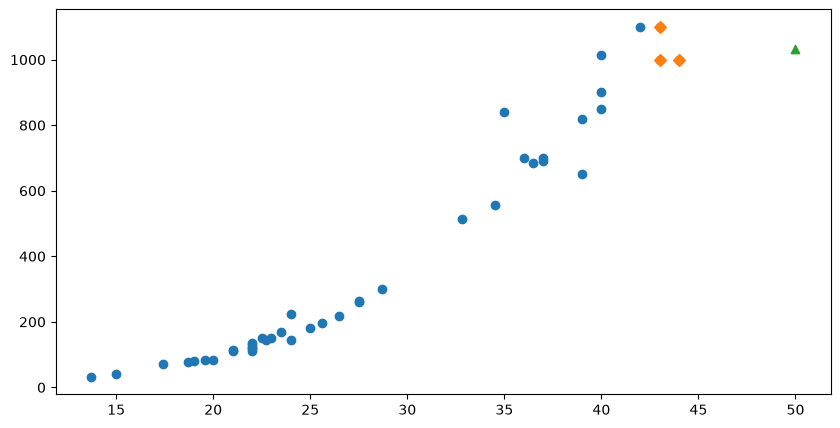

In [12]:
# 50cm인 생선으로 이웃 찾기
distance, indexes = knr.kneighbors([[50]])

# 훈련세트의 산점
plt.figure(figsize=(10, 5))
plt.scatter(train_input, train_target)

# 이웃 그리기
plt.scatter(
    train_input[indexes],
    train_target[indexes],
    marker='D'
)

# 50cm 생선 데이터
plt.scatter(
    50,
    1033,
    marker='^'
)

plt.show()

In [13]:
print(np.mean(train_target[indexes]))

1033.3333333333333


> kNN Regression은 주변 이웃의 값들의 평균을 구하는 것이므로 학습한 데이터의 범위를 벗어나게 되면 사용할 수 없음

#### 선형 회귀 ( Linear Regression )
: 직선이나 곡선의 함수식을 이용해 구하는 방식으로 로지스틱 회귀분석 & 인공신경망의 기초가 됨

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
# 모델
lr = LinearRegression()

# 학습
lr.fit(train_input, train_target)

LinearRegression()

In [17]:
# 50cm 생선의 무게에 대한 예측
lr.predict  ([[50]])

array([1241.83860323])

In [18]:
print(lr.coef_, lr.intercept_)

[39.01714496] -709.0186449535474


In [20]:
39.01714496 * 50 -709.0186449535474

1241.8386030464528

### 산점도 그리기

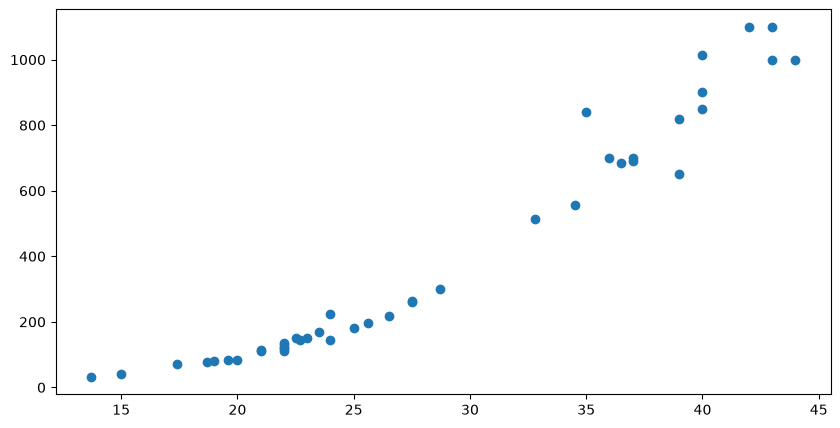

In [21]:
# 훈련세트의 산점도
plt.figure(figsize=(10, 5))
plt.scatter(train_input, train_target)
plt.show()